# PatrolIQ — Smart Safety Analytics Platform
**Chicago Crime Intelligence with Unsupervised ML**

This notebook walks step-by-step through the project, exactly mirroring the 9 steps in the brief:

1. Data acquisition & preprocessing
2. Exploratory data analysis
3. Feature engineering
4. Clustering (KMeans, DBSCAN, Hierarchical + temporal KMeans)
5. Dimensionality reduction (PCA + t-SNE)
6. *(Skipped in spec — numbering jumps to 7)*
7. MLflow experiment tracking
8. Streamlit application
9. Cloud deployment notes

Every cell can run end-to-end on the 77k-row Chicago CSV you uploaded. Swap the path at the top to use the full 7.8M-row dataset; the rest is identical.


## Setup

In [1]:
import os, json, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RAW_PATH = "/sessions/laughing-bold-gauss/mnt/uploads/6a4c3cd9-2e3d-46ff-a26a-ee92dab8c8f1-1778786136572_Crimes_-_2001_to_Present_20260515.csv"  # replace with your local path
SAMPLE_N = 500_000
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1 — Data Acquisition & Preprocessing
Load the CSV, parse dates, sort by recency, keep the most recent `SAMPLE_N`, then clean missing values and confine to the Chicago bounding box.

In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
df_raw["Date"] = pd.to_datetime(df_raw["Date"], errors="coerce")
df_raw = df_raw.sort_values("Date", ascending=False)
df = df_raw.head(SAMPLE_N).copy()

# Drop critical-NA rows; trim to Chicago bbox
df = df.dropna(subset=["Latitude","Longitude","Date","Primary Type"])
df = df[df["Latitude"].between(41.6, 42.05) & df["Longitude"].between(-87.95, -87.5)]
for c in ["Location Description","Description"]:
    df[c] = df[c].fillna("UNKNOWN")
for c in ["District","Ward","Community Area","Beat"]:
    df[c] = df[c].fillna(-1)
for c in ["Arrest","Domestic"]:
    df[c] = df[c].astype(str).str.lower().map({"true": True, "false": False}).fillna(False)
df = df.reset_index(drop=True)
print(f"Clean shape: {df.shape}")
df.head()

Raw shape: (77494, 22)


Clean shape: (76415, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14188288,JK243715,2026-05-06,021XX E 69TH ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,5,43.0,14,1191868.0,1859642.0,2026,05/13/2026 03:53:47 PM,41.769848,-87.572245,"(41.769848011, -87.572244938)"
1,14188587,JK244187,2026-05-06,040XX N CENTRAL PARK AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,...,45,16.0,06,1151669.0,1926666.0,2026,05/13/2026 03:53:47 PM,41.954651,-87.717836,"(41.954651304, -87.717836369)"
2,14190249,JK246023,2026-05-06,013XX N HUDSON AVE,0320,ROBBERY,STRONG ARM - NO WEAPON,SIDEWALK,False,False,...,27,8.0,03,1173069.0,1909480.0,2026,05/13/2026 03:53:47 PM,41.907044,-87.639678,"(41.907043531, -87.639678087)"
3,14190111,JK246122,2026-05-06,011XX W WASHBURNE AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,True,...,28,28.0,14,1168878.0,1894548.0,2026,05/13/2026 03:53:47 PM,41.866161,-87.655507,"(41.866161043, -87.655506578)"
4,14189113,JK244208,2026-05-06,039XX N MONTICELLO AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,APARTMENT,False,False,...,45,16.0,06,1151355.0,1925975.0,2026,05/13/2026 03:53:47 PM,41.952761,-87.719009,"(41.952761333, -87.719008899)"


## Step 2 — Exploratory Data Analysis
We answer three core questions: **what** crimes happen, **when**, and **where**.

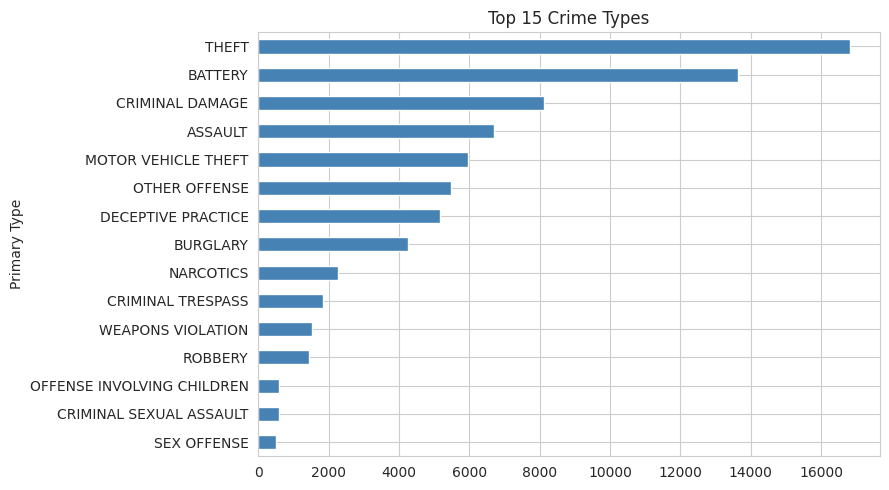

In [3]:
# Top crime types
top = df["Primary Type"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9,5))
top.plot(kind="barh", ax=ax, color="steelblue"); ax.invert_yaxis()
ax.set_title("Top 15 Crime Types"); plt.tight_layout(); plt.show()

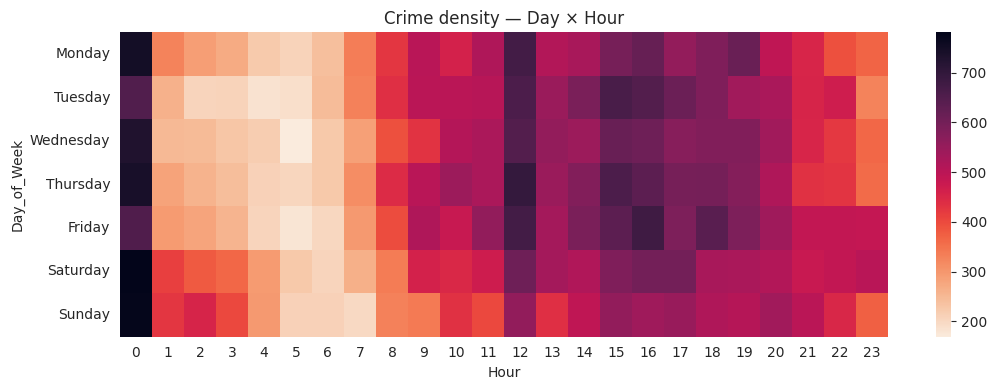

In [4]:
# Temporal extracts (used in EDA + step 3)
df["Hour"] = df["Date"].dt.hour
df["DOW_Num"] = df["Date"].dt.dayofweek
df["Day_of_Week"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
piv = df.pivot_table(index="Day_of_Week", columns="Hour", values="ID", aggfunc="count").reindex(dow_order)
fig, ax = plt.subplots(figsize=(11,4))
sns.heatmap(piv, cmap="rocket_r", ax=ax)
ax.set_title("Crime density — Day × Hour"); plt.tight_layout(); plt.show()

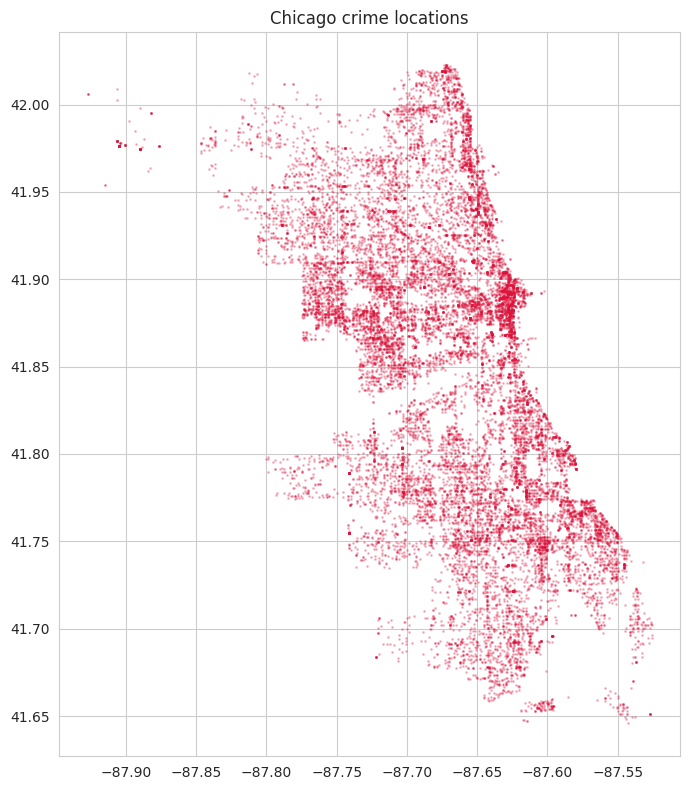

Arrest rate: 14.9% | Domestic rate: 19.1%


In [5]:
# Geographic scatter (sample for speed)
samp = df.sample(min(20_000, len(df)), random_state=1)
fig, ax = plt.subplots(figsize=(7,8))
ax.scatter(samp["Longitude"], samp["Latitude"], s=1, alpha=0.25, c="crimson")
ax.set_title("Chicago crime locations"); plt.tight_layout(); plt.show()
print(f"Arrest rate: {df['Arrest'].mean()*100:.1f}% | Domestic rate: {df['Domestic'].mean()*100:.1f}%")

## Step 3 — Feature Engineering
Cyclical encodings for hour/day/month so distance-based clusterers respect periodicity. A hand-curated severity score maps the 30+ crime types onto a 1–5 risk scale.

In [6]:
SEVERITY = {
    "HOMICIDE":5,"CRIM SEXUAL ASSAULT":5,"CRIMINAL SEXUAL ASSAULT":5,"KIDNAPPING":5,"ARSON":5,
    "ROBBERY":4,"ASSAULT":4,"BATTERY":4,"WEAPONS VIOLATION":4,"OFFENSE INVOLVING CHILDREN":4,"SEX OFFENSE":4,"HUMAN TRAFFICKING":5,
    "BURGLARY":3,"MOTOR VEHICLE THEFT":3,"NARCOTICS":3,"STALKING":3,"INTIMIDATION":3,
    "THEFT":2,"CRIMINAL DAMAGE":2,"CRIMINAL TRESPASS":2,"DECEPTIVE PRACTICE":2,
    "PUBLIC PEACE VIOLATION":2,"INTERFERENCE WITH PUBLIC OFFICER":2,
    "GAMBLING":1,"LIQUOR LAW VIOLATION":1,"OBSCENITY":1,"PUBLIC INDECENCY":1,"OTHER OFFENSE":1,
}
season_map = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}

df["Season"] = df["Month"].map(season_map)
df["Is_Weekend"] = df["DOW_Num"].isin([5,6])
df["Hour_sin"] = np.sin(2*np.pi*df["Hour"]/24); df["Hour_cos"] = np.cos(2*np.pi*df["Hour"]/24)
df["DOW_sin"]  = np.sin(2*np.pi*df["DOW_Num"]/7); df["DOW_cos"] = np.cos(2*np.pi*df["DOW_Num"]/7)
df["Month_sin"]= np.sin(2*np.pi*(df["Month"]-1)/12); df["Month_cos"] = np.cos(2*np.pi*(df["Month"]-1)/12)
df["Crime_Severity_Score"] = df["Primary Type"].map(SEVERITY).fillna(2).astype(int)
df["PrimaryType_Code"] = df["Primary Type"].astype("category").cat.codes
df["LocDesc_Code"]     = df["Location Description"].astype("category").cat.codes
df[["Hour","Day_of_Week","Season","Is_Weekend","Crime_Severity_Score"]].head()

,Hour,Day_of_Week,Season,Is_Weekend,Crime_Severity_Score
0,0,Wednesday,Spring,False,2
1,0,Wednesday,Spring,False,3
2,0,Wednesday,Spring,False,4
3,0,Wednesday,Spring,False,2
4,0,Wednesday,Spring,False,3


## Step 4 — Clustering
Three algorithms on lat/lon, plus a temporal KMeans. We score each with silhouette and Davies–Bouldin.

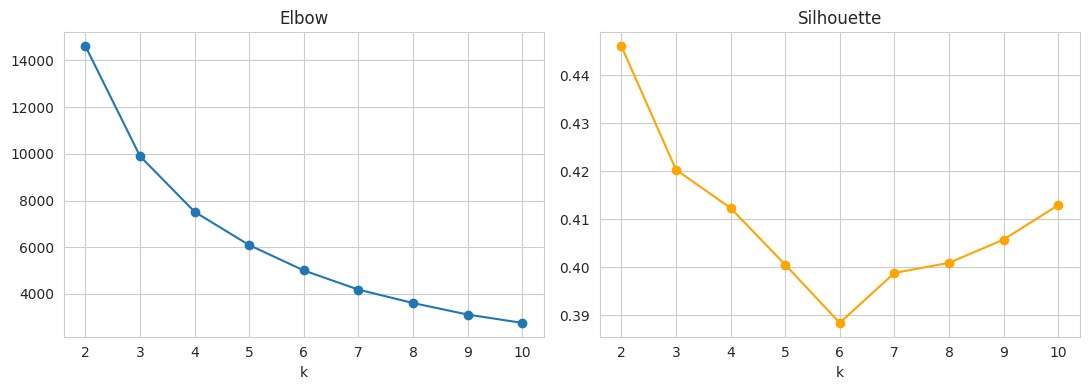

In [7]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

geo = df[["Latitude","Longitude"]].values
geo_z = StandardScaler().fit_transform(geo)
idx = np.random.RandomState(RANDOM_STATE).choice(len(geo), min(15_000, len(geo)), replace=False)

# Elbow + silhouette sweep
inertias, sils = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(geo_z[idx])
    inertias.append(km.inertia_); sils.append(silhouette_score(geo_z[idx], km.labels_, sample_size=5000, random_state=42))
fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].plot(range(2,11), inertias, "o-"); axes[0].set_title("Elbow"); axes[0].set_xlabel("k")
axes[1].plot(range(2,11), sils, "o-", color="orange"); axes[1].set_title("Silhouette"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

KMeans   k=8  silhouette=0.415  DB=0.782
DBSCAN   clusters=4  noise=1.7%  sil=0.168
Hierarchical k=8  silhouette=0.356


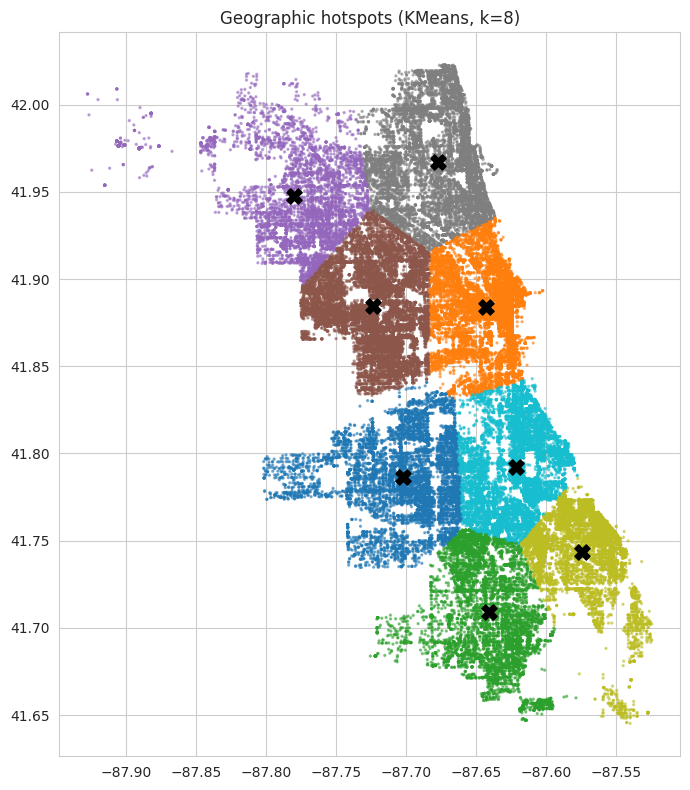

In [8]:
# Practical hotspot deployment: project asks for 5-10 hotspots; pick k=8
K = 8
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(geo)
df["geo_kmeans"] = km.labels_
km_sil = silhouette_score(geo[idx], km.predict(geo[idx]), sample_size=5000, random_state=42)
km_db  = davies_bouldin_score(geo[idx], km.predict(geo[idx]))

# DBSCAN
db = DBSCAN(eps=0.15, min_samples=30).fit(geo_z[idx])
mask = db.labels_ != -1
db_sil = silhouette_score(geo_z[idx][mask], db.labels_[mask], sample_size=5000, random_state=42) if mask.sum()>100 else np.nan

# Hierarchical
hc = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(geo_z[idx])
hc_sil = silhouette_score(geo_z[idx], hc.labels_, sample_size=5000, random_state=42)

print(f"KMeans   k={K}  silhouette={km_sil:.3f}  DB={km_db:.3f}")
print(f"DBSCAN   clusters={len(set(db.labels_))-1}  noise={(db.labels_==-1).mean()*100:.1f}%  sil={db_sil:.3f}")
print(f"Hierarchical k={K}  silhouette={hc_sil:.3f}")

fig, ax = plt.subplots(figsize=(7,8))
ax.scatter(df["Longitude"], df["Latitude"], c=df["geo_kmeans"], s=2, cmap="tab10", alpha=0.5)
ax.scatter(km.cluster_centers_[:,1], km.cluster_centers_[:,0], c="black", marker="X", s=120)
ax.set_title(f"Geographic hotspots (KMeans, k={K})"); plt.tight_layout(); plt.show()

In [9]:
# Hotspot summary table
hot = df.groupby("geo_kmeans").agg(
    n=("ID","size"),
    top_crime=("Primary Type", lambda s: s.value_counts().index[0]),
    arrest_rate=("Arrest","mean"),
    severity=("Crime_Severity_Score","mean"),
    lat=("Latitude","mean"), lon=("Longitude","mean"),
).round(3).sort_values("n", ascending=False)
hot

,n,top_crime,arrest_rate,severity,lat,lon
geo_kmeans,,,,,,
1,14177,THEFT,0.128,2.612,41.884,-87.643
4,13355,BATTERY,0.212,2.893,41.885,-87.723
7,10472,BATTERY,0.143,2.853,41.792,-87.621
5,10269,THEFT,0.116,2.623,41.967,-87.677
0,7917,THEFT,0.151,2.801,41.786,-87.702
6,7579,BATTERY,0.119,2.888,41.743,-87.575
2,7212,BATTERY,0.160,2.801,41.709,-87.640
3,5434,THEFT,0.148,2.705,41.948,-87.780


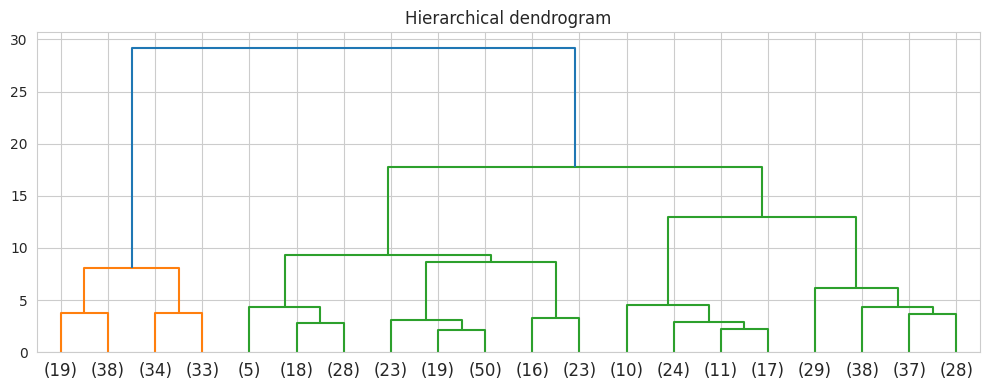

In [10]:
# Dendrogram (small subsample so it renders cleanly)
sub = geo_z[np.random.RandomState(0).choice(len(geo_z), 500, replace=False)]
Z = linkage(sub, method="ward")
fig, ax = plt.subplots(figsize=(10,4))
dendrogram(Z, truncate_mode="lastp", p=20, ax=ax)
ax.set_title("Hierarchical dendrogram"); plt.tight_layout(); plt.show()

In [11]:
# Temporal KMeans — group similar time-of-day / day-of-week / severity profiles
T_feats = ["Hour_sin","Hour_cos","DOW_sin","DOW_cos","Month_sin","Month_cos","Crime_Severity_Score"]
T = StandardScaler().fit_transform(df[T_feats].values)
sils_t = [silhouette_score(T[idx], KMeans(n_clusters=k, n_init=10, random_state=42).fit(T[idx]).labels_, sample_size=5000, random_state=42)
          for k in range(2,8)]
best_kt = int(np.argmax(sils_t) + 2)
km_t = KMeans(n_clusters=best_kt, n_init=10, random_state=42).fit(T)
df["temporal_kmeans"] = km_t.labels_

df.groupby("temporal_kmeans").agg(
    n=("ID","size"), avg_hour=("Hour","mean"),
    weekend_pct=("Is_Weekend","mean"), severity=("Crime_Severity_Score","mean"),
).round(2)

,n,avg_hour,weekend_pct,severity
temporal_kmeans,,,,
0,40963,12.62,0.29,2.79
1,35452,12.30,0.28,2.74


## Step 5 — Dimensionality Reduction (PCA + t-SNE)

Components for >=70% variance: 8
Variance explained: [0.214 0.101 0.093 0.089 0.062 0.057 0.054 0.053 0.05  0.049]


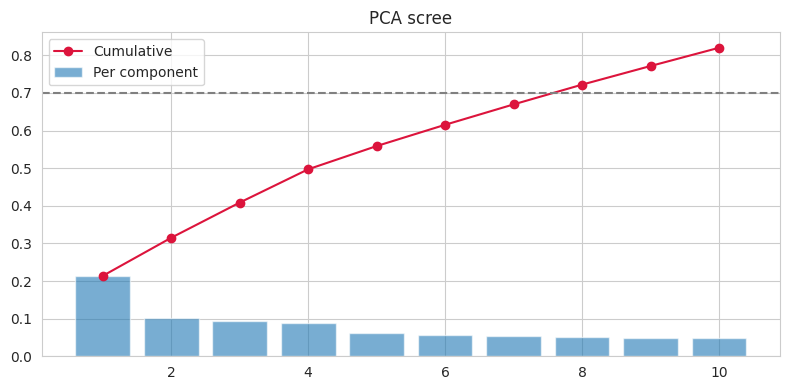

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

features = ["Latitude","Longitude","Hour_sin","Hour_cos","DOW_sin","DOW_cos",
            "Month_sin","Month_cos","Crime_Severity_Score","Is_Weekend",
            "PrimaryType_Code","LocDesc_Code","District","Ward","Community Area",
            "Beat","Arrest","Domestic","Year"]
X = df[features].copy()
for c in ["Is_Weekend","Arrest","Domestic"]:
    X[c] = X[c].astype(int)
X = X.fillna(0).values
Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=10).fit(Xz)
cum = pca.explained_variance_ratio_.cumsum()
n70 = int(np.searchsorted(cum, 0.70) + 1)
print(f"Components for >=70% variance: {n70}")
print("Variance explained:", np.round(pca.explained_variance_ratio_, 3))

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(1,11), pca.explained_variance_ratio_, alpha=0.6, label="Per component")
ax.plot(range(1,11), cum, "o-", color="crimson", label="Cumulative")
ax.axhline(0.70, ls="--", color="gray"); ax.legend(); ax.set_title("PCA scree")
plt.tight_layout(); plt.show()

In [13]:
# Top features driving PC1
loadings = pd.DataFrame(pca.components_[:3].T, index=features, columns=["PC1","PC2","PC3"])
loadings["abs_PC1"] = loadings["PC1"].abs()
loadings.sort_values("abs_PC1", ascending=False).head(5)

,PC1,PC2,PC3,abs_PC1
District,0.444522,0.038767,-0.010305,0.444522
Beat,0.444211,0.038689,-0.010449,0.444211
Latitude,0.435738,0.008617,-0.000313,0.435738
Ward,0.418261,0.014499,0.002590,0.418261
Community Area,-0.351748,0.003601,-0.003129,0.351748


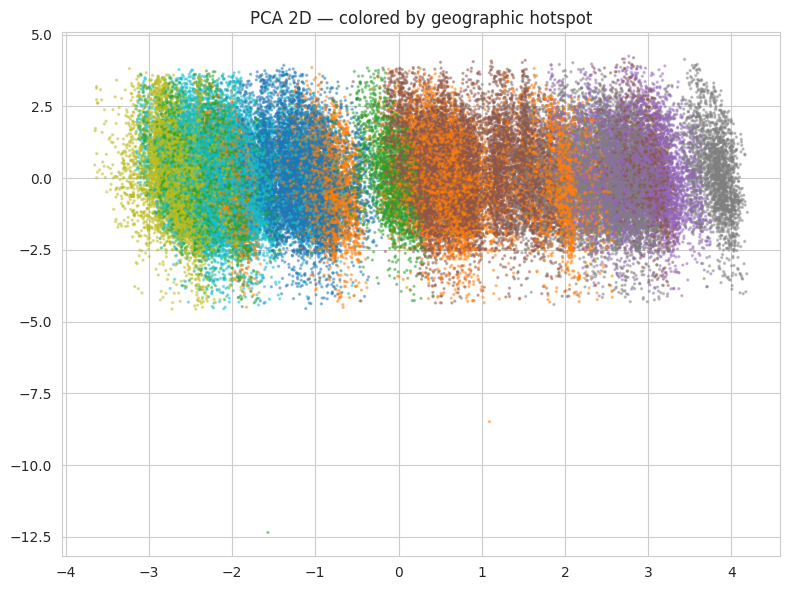

In [14]:
# 2D PCA scatter colored by hotspot
pcs = PCA(n_components=2).fit_transform(Xz)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(pcs[:,0], pcs[:,1], c=df["geo_kmeans"], cmap="tab10", s=2, alpha=0.4)
ax.set_title("PCA 2D — colored by geographic hotspot"); plt.tight_layout(); plt.show()

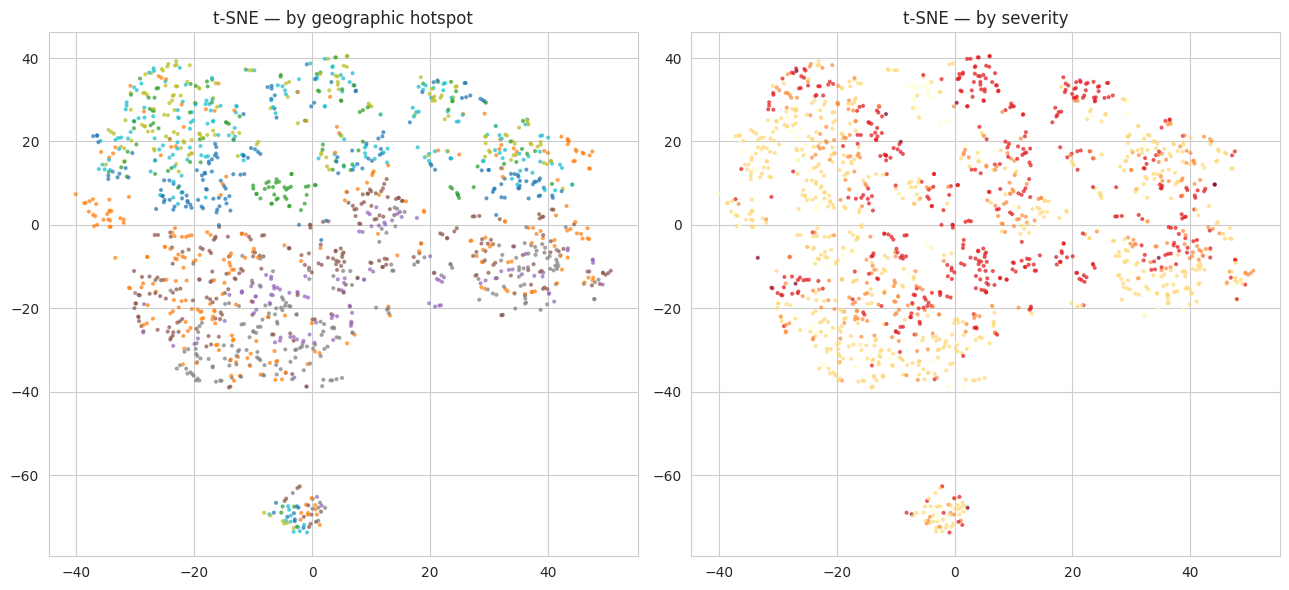

In [15]:
# t-SNE on a sample (slow on large data)
sub_idx = np.random.RandomState(42).choice(len(Xz), 1500, replace=False)
emb = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
           random_state=42).fit_transform(Xz[sub_idx])
fig, axes = plt.subplots(1,2, figsize=(13,6))
axes[0].scatter(emb[:,0], emb[:,1], c=df["geo_kmeans"].values[sub_idx], cmap="tab10", s=4, alpha=0.6)
axes[0].set_title("t-SNE — by geographic hotspot")
axes[1].scatter(emb[:,0], emb[:,1], c=df["Crime_Severity_Score"].values[sub_idx], cmap="YlOrRd", s=4, alpha=0.6)
axes[1].set_title("t-SNE — by severity"); plt.tight_layout(); plt.show()

## Step 7 — MLflow Experiment Tracking
Log every clustering / DR variant so you can rank them later. Point Streamlit at the same `mlruns/` folder to surface the results in the UI.

In [16]:
import mlflow
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("PatrolIQ_Clustering")

for k in [3, 5, 8, 10]:
    with mlflow.start_run(run_name=f"KMeans_k{k}"):
        m = KMeans(n_clusters=k, n_init=10, random_state=42).fit(geo)
        sil = silhouette_score(geo[idx], m.predict(geo[idx]), sample_size=5000, random_state=42)
        dbi = davies_bouldin_score(geo[idx], m.predict(geo[idx]))
        mlflow.log_params({"algorithm":"KMeans","k":k})
        mlflow.log_metrics({"silhouette":float(sil),"davies_bouldin":float(dbi),"inertia":float(m.inertia_)})

for eps in [0.10, 0.15, 0.25]:
    with mlflow.start_run(run_name=f"DBSCAN_eps{eps}"):
        m = DBSCAN(eps=eps, min_samples=30).fit(geo_z[idx])
        n_clusters = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
        mlflow.log_params({"algorithm":"DBSCAN","eps":eps,"min_samples":30})
        mlflow.log_metrics({"n_clusters":n_clusters,"noise_pct":float((m.labels_==-1).mean())})

print("MLflow runs written to ./mlruns — view with `mlflow ui`")

MLflow runs written to ./mlruns — view with `mlflow ui`
